# Customer Support From Twitter
https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter

# Import

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load Dataset

In [2]:
from google.colab import files
uploaded  = files.upload()


Saving tickets_English.csv to tickets_English.csv


In [5]:
tickets = pd.read_csv("tickets_English.csv")

## Orignal Data Cleaning and EDA
- done previously and resulted data saved, so that we can load it directly as: `tickets_English.csv`

In [ ]:
# -------------------------------------previous cleaning done:
### took only 300K rows
# ######## 1- Filter only customer tickets using `inbound == True`

# tickets = df_300K[df_300K["inbound"] == True].copy()

# print("Shape after keeping inbound tweets only:", tickets.shape)
# display(tickets.head())
# print("shape", tickets.shape)

# #shape (164122, 7)


# ########  2- keep only needed columns
# # - `author_id` not needed
# # - `inbound` not needed any more
# # - `response_tweet_id` not needed
# # - `in_response_to_tweet_id` not needed
# # - `created_at` not needed
# # - `tweet_id` nor needed

# #   "author_id"
# cols_to_keep = [
#     "text"
# ]

# tickets = tickets[cols_to_keep].copy()
# print(tickets.shape)
# display(tickets.head())
# #(164122, 3)


# ######## 3- Remove unusable rows
# Now remove rows that are bad for training:
# - null text
# - duplicates
# - very short junk

# tickets = tickets.dropna(subset=["text"]).copy() # drop missing text

# tickets["text"] = tickets["text"].astype(str).str.strip() # remove spaces

# tickets = tickets[tickets["text"].str.len() > 10].copy() # remove less 10 char

# tickets = tickets.drop_duplicates(subset=["text"]).copy() # remove duplicates

# print("Shape after cleaning unusable rows:", tickets.shape)

# #(162593, 3)


# ######## 4- English Only Filtering
# - so that embeddings work better
# - ML features gets generated cleaner.

# !pip install langdetect
# from langdetect import detect

# def is_english(text):
#     try:
#         return detect(text) == "en"
#     except:
#         return False

# tickets = tickets[tickets["text"].apply(is_english)]
# # (149254, 1)


# # -------------------------------------previous EDA done:
# print("Inbound distribution:")
# display(df_300K["inbound"].value_counts(dropna=False).to_frame(name='count').assign(percentage=lambda x: (x['count'] / x['count'].sum() * 100).map('{:.2f}%'.format))) # Add percentages

# print("\nText length summary:")
# display(df_300K["text"].astype(str).str.len().describe())

# # print random text samples to understand what is going on
# print("\nRandom text samples:")
# display(df_300K["text"].dropna().sample(5, random_state=42).tolist())


# 1- Inspect dataset
- shape
- head
- missing values
- info

In [6]:
print("Shape:", tickets.shape)

display(tickets.head(5))

print("\nMissing values:")
display(tickets.isna().sum().sort_values(ascending=False))

Shape: (149254, 1)


,text
0,@161252 What's that egg website people talk about
1,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...
2,@331912 @115955 Thats better than having an un...
3,@VirginAmerica is probably one of the best air...
4,@AlaskaAir Phone system seems to be down



Missing values:


,0
text,0


In [7]:
tickets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149254 entries, 0 to 149253
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    149254 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB


# 2 - Cleaning Text Pipeline and Feature Engineering Pipeline

### 1- Create raw and clean text columns
Important:

- `text` stays as the original raw ticket text for punctuation/caps features
- `text_clean` is used for keyword matching and later text/RAG work

In [8]:
import re
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


def clean_text(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"http\S+|www\S+", "", text) # remove URLs
    text = re.sub(r"@\w+", "", text)           # remove mentions
    text = re.sub(r"[^\x00-\x7F]+", "", text)  # remove emojies
    text = re.sub(r"\s+", " ", text).strip()   # normalize spaces
    return text


class TicketTextCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        cleaned_data = X.copy()
        cleaned_data["text"] = cleaned_data["text"].astype(str).str.strip()
        cleaned_data["text_clean"] = cleaned_data["text"].apply(clean_text)

        return cleaned_data


cleaning_pipeline = Pipeline([
    ("cleaner", TicketTextCleaner())
])

# apply for tickets NOW to be able to generate labels
tickets = cleaning_pipeline.fit_transform(tickets)

# check pipeline
acceptance_check = cleaning_pipeline.transform(pd.DataFrame({
    "text": ["HELP!!! I was charged twice 😡 @support http://example.com"]
}))
assert acceptance_check.loc[0, "text_clean"] == "help!!! i was charged twice"

display(tickets[["text", "text_clean"]].head(10))
display(acceptance_check)


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,text,text_clean
0,@161252 What's that egg website people talk about,what's that egg website people talk about
1,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,why! #ios11
2,@331912 @115955 Thats better than having an un...,thats better than having an unstable connectio...
3,@VirginAmerica is probably one of the best air...,is probably one of the best airlines i've ever...
4,@AlaskaAir Phone system seems to be down,phone system seems to be down
5,@Uber_Support Reports are there are 68 Ubers w...,reports are there are 68 ubers waiting for pas...
6,@AmazonHelp Saw that but only after a labored ...,saw that but only after a labored hunt. bigger...
7,@British_Airways Ok. Will check with them. Tha...,"ok. will check with them. thanks. also, kudos ..."
8,@AmazonHelp Give me the contact number of CLOU...,give me the contact number of cloudtail india ...
9,@ChipotleTweets It’s pretty bad. But at least ...,its pretty bad. but at least the queso is good!


,text,text_clean
0,HELP!!! I was charged twice 😡 @support http://...,help!!! i was charged twice


### 5- Inspect Again

In [9]:
tickets.head(5)

,text,text_clean
0,@161252 What's that egg website people talk about,what's that egg website people talk about
1,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,why! #ios11
2,@331912 @115955 Thats better than having an un...,thats better than having an unstable connectio...
3,@VirginAmerica is probably one of the best air...,is probably one of the best airlines i've ever...
4,@AlaskaAir Phone system seems to be down,phone system seems to be down


# 5- Feature Engineering Pipeline
- reusable feature engineering for real-time prediction

In [10]:
# urgent keywords (strong signal)
urgent_keywords = [
    "refund", "charged", "cancel", "broken",
    "not working", "down", "failed", "error", "critical",
    "unresolved", "quit", "money back", "legal", "cancellation", "manager"
    , "supervisor", "urgent", "emergency", "asap", "locked out", "fraud", "dispute",
    "disappointed"
]

# Escalation phrases (moderate signal)
escalation_keywords = [
    "still", "again", "waiting", "no response", "second time",
    "third time", "useless", "complicated", "difficult"
]

# upset keywords (supporting signal)
upset_keywords = [
    "fuck", "fucking", "freaking", "ridiculous", "annoying", "frustrating",
    "disappointed", "unacceptable", "terrible", "hate", "upset", "awful"
]



In [11]:
FEATURE_COLUMNS = [
    "word_count",
    "question_count",
    "exclamation_count",
    "caps_ratio",
    "urgent_kw_count",
    "escalation_kw_count",
    "upset_kw_count"
]


def count_keywords(text, keywords):
    return sum(1 for kw in keywords if kw in str(text))


def count_exclamations(text):
    return str(text).count("!")


def count_questions(text):
    return str(text).count("?")


def caps_ratio(text):
    letters = [c for c in str(text) if c.isalpha()]
    if len(letters) == 0:
        return 0.0
    caps = sum(1 for c in letters if c.isupper())
    return caps / len(letters)


def punctuation_score(excl, ques):
    total = excl + ques

    if total >= 5:
        return 2
    elif total >= 2:
        return 1
    else:
        return 0


class TicketFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        features = X.copy()

        features["word_count"] = features["text"].str.split().str.len()
        features["question_count"] = features["text"].apply(count_questions).clip(upper=10)
        features["exclamation_count"] = features["text"].apply(count_exclamations).clip(upper=10)
        features["caps_ratio"] = features["text"].apply(caps_ratio)
        features["urgent_kw_count"] = features["text_clean"].apply(lambda text: count_keywords(text, urgent_keywords))
        features["escalation_kw_count"] = features["text_clean"].apply(lambda text: count_keywords(text, escalation_keywords))
        features["upset_kw_count"] = features["text_clean"].apply(lambda text: count_keywords(text, upset_keywords))

        return features


feature_engineering_pipeline = Pipeline([
    ("features", TicketFeatureEngineer())
])

ticket_preprocessing_pipeline = Pipeline([
    ("cleaner", TicketTextCleaner()),
    ("features", TicketFeatureEngineer())
])

# apply for tickets NOW to be able to generate labels
tickets = feature_engineering_pipeline.fit_transform(tickets)


# check pipeline
feature_acceptance_check = ticket_preprocessing_pipeline.transform(pd.DataFrame({
    "text": ["HELP!!! I was charged twice 😡 @support http://example.com"]
}))

display(feature_acceptance_check[["text", "text_clean"] + FEATURE_COLUMNS])


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,text,text_clean,word_count,question_count,exclamation_count,caps_ratio,urgent_kw_count,escalation_kw_count,upset_kw_count
0,HELP!!! I was charged twice 😡 @support http://...,help!!! i was charged twice,8,0,3,0.121951,1,0,0


In [13]:
tickets.head()

,text,text_clean,word_count,question_count,exclamation_count,caps_ratio,urgent_kw_count,escalation_kw_count,upset_kw_count
0,@161252 What's that egg website people talk about,what's that egg website people talk about,8,0,0,0.029412,0,0,0
1,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,why! #ios11,4,0,1,0.277778,0,0,0
2,@331912 @115955 Thats better than having an un...,thats better than having an unstable connectio...,14,0,0,0.016949,0,0,0
3,@VirginAmerica is probably one of the best air...,is probably one of the best airlines i've ever...,11,0,0,0.049180,0,0,0
4,@AlaskaAir Phone system seems to be down,phone system seems to be down,7,0,0,0.090909,1,0,0


In [14]:
# notebook-only scoring rule used to create the training label
def compute_priority(row):
    score = 0

    # strong signals
    if row["urgent_kw_count"] > 0:
        score += 2

    # moderate signals
    if row["escalation_kw_count"] > 0:
        score += 1

    # emotion signals
    if row["upset_kw_count"] > 0:
        score += 1

    # punctuation signal
    score += punctuation_score(
        row["exclamation_count"],
        row["question_count"]
    )

    if row["caps_ratio"] > 0.3:
        score += 1

    return "urgent" if score > 2 else "normal"

# apply notebook-only label
tickets["priority"] = tickets.apply(compute_priority, axis=1)

# check distribution
print(tickets["priority"].value_counts())

# normal    139876
# urgent      6525

priority
normal    142724
urgent      6530
Name: count, dtype: int64


In [16]:
tickets.head()

,text,text_clean,word_count,question_count,exclamation_count,caps_ratio,urgent_kw_count,escalation_kw_count,upset_kw_count,priority
0,@161252 What's that egg website people talk about,what's that egg website people talk about,8,0,0,0.029412,0,0,0,normal
1,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,why! #ios11,4,0,1,0.277778,0,0,0,normal
2,@331912 @115955 Thats better than having an un...,thats better than having an unstable connectio...,14,0,0,0.016949,0,0,0,normal
3,@VirginAmerica is probably one of the best air...,is probably one of the best airlines i've ever...,11,0,0,0.049180,0,0,0,normal
4,@AlaskaAir Phone system seems to be down,phone system seems to be down,7,0,0,0.090909,1,0,0,normal


In [20]:
# check
tickets.sample(10)[["text", "priority"]]

,text,priority
16702,@Tesco hi! Can you please tell me which prosec...,normal
12215,@VirginTrains once again you cancel a train on...,urgent
116840,@ArgosHelpers Been there done that - no help. ...,normal
691,@AldiUK Really enjoying shopping in Aldi fanta...,normal
82781,@Safaricom_Care I deleted the message kindly u...,normal
105022,@ATVIAssist @691995 When will the fix go live?,normal
8894,my phones glitching out so bad because of the ...,normal
12172,@AskAmex I've tried three different browsers. :(,normal
113573,"@486007 Not yet, probably lined up for tomorrow",normal
35543,@313975 @115714 Omg it does suck! We have spri...,normal


# 6- Some EDA on Engineered features
- Features are now created by `TicketFeatureEngineer`
- `has_digits` was not kept because it was weak/uninformative

#### 1- .describe()

In [21]:
tickets[FEATURE_COLUMNS].describe().T

# exclamation_count and question_count are capped by TicketFeatureEngineer
# word_count is inspected here before applying the notebook-only short-ticket filter

,count,mean,std,min,25%,50%,75%,max
word_count,149254.0,19.671848,10.305665,1.0,12.000000,19.0000,25.000000,77.0
question_count,149254.0,0.359401,0.719415,0.0,0.000000,0.0000,1.000000,10.0
exclamation_count,149254.0,0.280327,0.822029,0.0,0.000000,0.0000,0.000000,10.0
caps_ratio,149254.0,0.080472,0.082941,0.0,0.039548,0.0625,0.096774,1.0
urgent_kw_count,149254.0,0.135179,0.384840,0.0,0.000000,0.0000,0.000000,4.0
escalation_kw_count,149254.0,0.101311,0.325456,0.0,0.000000,0.0000,0.000000,4.0
upset_kw_count,149254.0,0.056896,0.265348,0.0,0.000000,0.0000,0.000000,4.0


#### Fix issues spotted
- `exclamation_count` and `question_count` are capped inside `TicketFeatureEngineer`
- Drop tweets with `word_count` <= 3 from the training notebook only

In [22]:
# training-data filter only; do not drop rows inside the real-time feature pipeline
tickets = tickets[tickets["word_count"] > 3].copy()

In [23]:
# check missing values
print(tickets.isna().sum())

# no missing

text                   0
text_clean             0
word_count             0
question_count         0
exclamation_count      0
caps_ratio             0
urgent_kw_count        0
escalation_kw_count    0
upset_kw_count         0
priority               0
dtype: int64


#### 2- Compare features with class to asses our labeling strategy

In [24]:
eda_df = tickets.groupby("priority").mean(numeric_only=True).T
display(eda_df)

# its good
# Strong features: urgent count, escalation, upset, word_count ...
# all features has positive correlation with the urgent label


priority,normal,urgent
word_count,19.724226,26.049870
question_count,0.346867,0.749425
exclamation_count,0.249171,0.979592
caps_ratio,0.077772,0.090536
urgent_kw_count,0.095866,1.037134
escalation_kw_count,0.086908,0.448519
upset_kw_count,0.044290,0.348780


#### 3- Correlation check

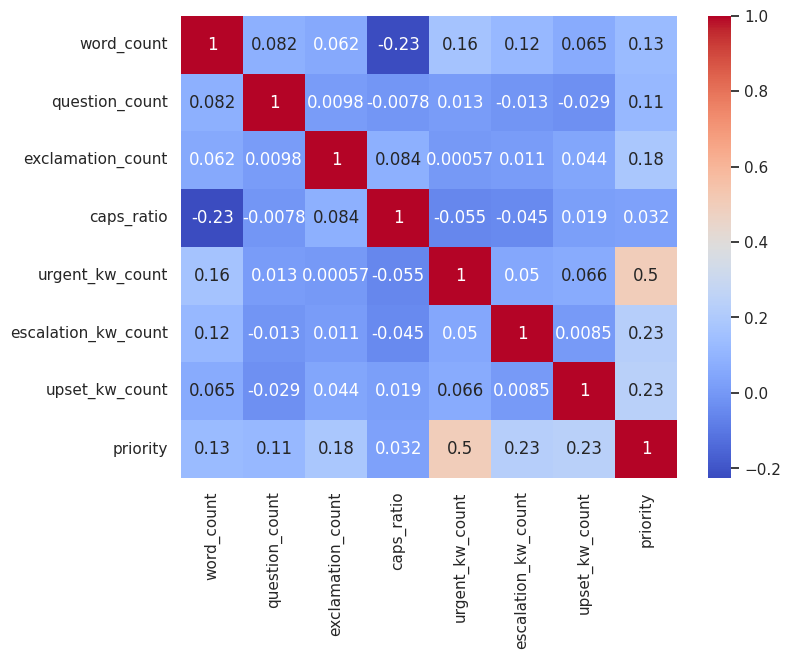

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

priority_num = tickets["priority"].map({"normal": 0, "urgent": 1})

X_corr = tickets[[
    "word_count",
    "question_count",
    "exclamation_count",
    "caps_ratio",
    "urgent_kw_count",
    "escalation_kw_count",
    "upset_kw_count"
]]

corr_df = X_corr.copy()
corr_df["priority"] = priority_num

plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
plt.show()

# urgent count WINS: 0.5 corr
# This is expected since the labeling rule partially depends on these keywords (weak supervision).
# then comes: "escalation_kw_count" and "upset_kw_count": 0.23 by 0.23

#### 4- plot distribution


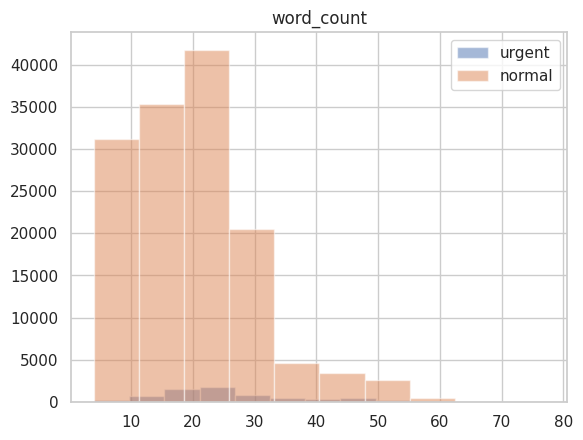

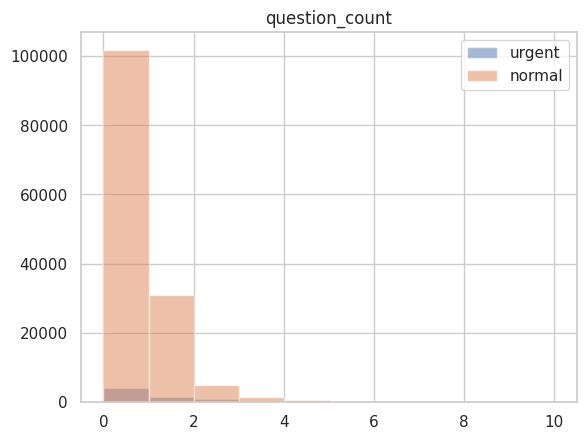

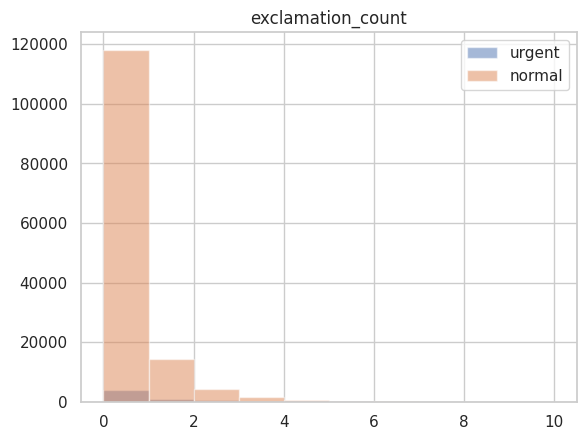

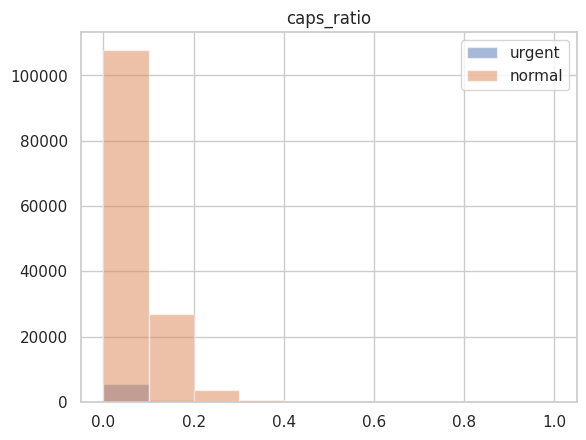

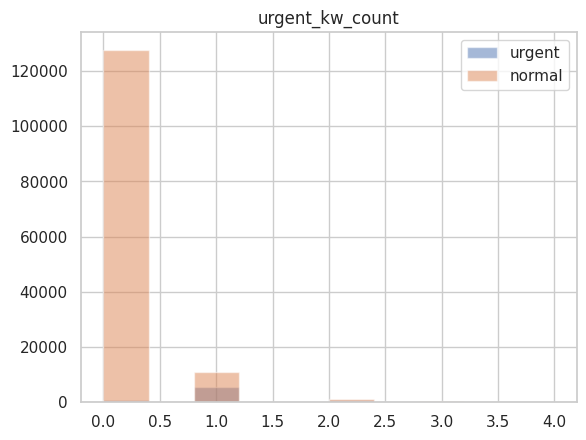

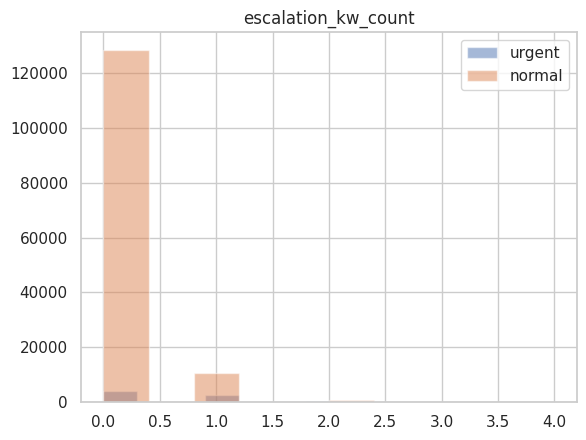

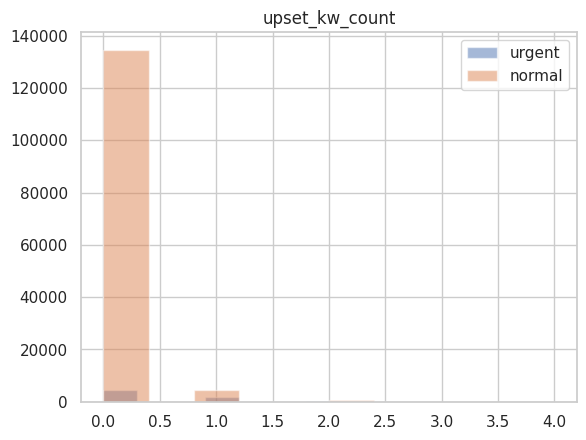

In [26]:
import matplotlib.pyplot as plt

features = [
     "word_count",
    "question_count",
    "exclamation_count",
    "caps_ratio",
    "urgent_kw_count",
    "escalation_kw_count",
    "upset_kw_count"
]
eda_df = pd.concat([tickets[features], tickets["priority"]], axis=1)

for f in features:
    plt.figure()
    eda_df[eda_df["priority"]=="urgent"][f].hist(alpha=0.5, label="urgent")
    eda_df[eda_df["priority"]=="normal"][f].hist(alpha=0.5, label="normal")
    plt.title(f)
    plt.legend()
    plt.show()

  # the best correlated one is urgent_count

#### 5- Class balance

In [27]:
print(tickets["priority"].value_counts(normalize=True))

# very un_balanced:
# normal    0.955482
# urgent    0.044518
# will apply balancing while modeling

priority
normal    0.955482
urgent    0.044518
Name: proportion, dtype: float64


# 6- Split

In [28]:
from sklearn.model_selection import train_test_split

# X contains only the raw user-facing input.
X = tickets[["text"]].copy() # double brackets returns a DataFrame (2D)
y = tickets["priority"].copy()

# 1) train temp split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y, # keeps Labels proportations similar across splits
    random_state=42
)

# 2) split temp into val/test: 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape) # (102472, 1)
print("Val shape:", X_val.shape)     # (21958, 1)
print("Test shape:", X_test.shape)   # (21959, 1)

# distribution of labels across splits ( to check imbalance)
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

print("\nVal label distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (102472, 1)
Val shape: (21958, 1)
Test shape: (21959, 1)

Train label distribution:
priority
normal    0.955481
urgent    0.044519
Name: proportion, dtype: float64

Val label distribution:
priority
normal    0.955506
urgent    0.044494
Name: proportion, dtype: float64

Test label distribution:
priority
normal    0.955462
urgent    0.044538
Name: proportion, dtype: float64


# 8- Data preprocessing
- imputation (not needed, no missing)
- encoding (no categoricals)
- scaling (applied)
- balancing (applied while training)

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# define the numeric preprocessing used by every model.
numeric_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("scaler", StandardScaler())
            ]),
            FEATURE_COLUMNS
        )
    ],
    remainder="drop"
)


def make_full_prediction_pipeline(model):
    # This is the full real-time prediction path:
    # raw text -> clean text -> engineered features -> scale features -> predict label
    return Pipeline([
        ("cleaner", TicketTextCleaner()),
        ("features", TicketFeatureEngineer()),
        ("preprocessor", numeric_preprocessor),
        ("model", model)
    ])


def save_model_result(model_name, y_true, y_pred):
    # Store the same important validation metrics for every model.
    return {
        "model": model_name,
        "precision_urgent": precision_score(y_true, y_pred, pos_label="urgent", zero_division=0),
        "recall_urgent": recall_score(y_true, y_pred, pos_label="urgent", zero_division=0),
        "f1_urgent": f1_score(y_true, y_pred, pos_label="urgent", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }


def label_to_int(y):
    # XGBoost needs numeric labels: normal=0, urgent=1.
    return y.map({"normal": 0, "urgent": 1})


def int_to_label(predictions):
    # Convert XGBoost numeric predictions back to text labels.
    return pd.Series(predictions).map({0: "normal", 1: "urgent"}).to_numpy()


model_results = []


In [36]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

# Step 1: create a full pipeline using Logistic Regression
logistic_pipeline = make_full_prediction_pipeline(
    LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )
)

# Step 2: train
logistic_pipeline.fit(X_train, y_train)

# Step 3: predict on val
logistic_val_pred = logistic_pipeline.predict(X_val)

# Step 4: compute key metrics for val
print("Classification report:")
print(classification_report(y_val, logistic_val_pred, zero_division=0))

print("Confusion matrix:")
cm = confusion_matrix(y_val, logistic_val_pred, labels=["normal", "urgent"])
cm_df = pd.DataFrame(
    cm,
    index=["actual_normal", "actual_urgent"],
    columns=["pred_normal", "pred_urgent"]
)
display(cm_df)

# Step 6: save summary metrics
model_results.append(save_model_result("logistic_regression", y_val, logistic_val_pred))

# MY ANALYSIS
# Missed only 1 urgent → excellent
# Flagged 631 normals as urgent → slightly aggressive
# but making false-positives (normal as urgent) is better than making false negatives (urgent as normal)
# since we are focused on capturing the urgent ones.

#accuracy = 0.97
# but dataset is 96.6% normal, so even a dumb model predicting only “normal” would get ~96%
# So: do not rely on accuracy

Classification report:
              precision    recall  f1-score   support

      normal       1.00      0.97      0.98     20981
      urgent       0.61      1.00      0.76       977

    accuracy                           0.97     21958
   macro avg       0.80      0.98      0.87     21958
weighted avg       0.98      0.97      0.97     21958

Confusion matrix:


,pred_normal,pred_urgent
actual_normal,20350,631
actual_urgent,1,976


In [37]:
# Step 1: create a full pipeline using Random Forest as the model.
random_forest_pipeline = make_full_prediction_pipeline(
    RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
)

# Step 2: train on the dataframe that contains raw ticket text.
random_forest_pipeline.fit(X_train, y_train)

# Step 3: predict on the validation dataframe.
random_forest_val_pred = random_forest_pipeline.predict(X_val)

# Step 4: evaluate validation performance.
print("Random Forest validation report:")
print(classification_report(y_val, random_forest_val_pred, zero_division=0))

cm = confusion_matrix(y_val, random_forest_val_pred, labels=["normal", "urgent"])
cm_df = pd.DataFrame(
    cm,
    index=["actual_normal", "actual_urgent"],
    columns=["pred_normal", "pred_urgent"]
)

print("\nConfusion Matrix:")
display(cm_df)

# Step 5: save summary metrics for comparison later.
model_results.append(save_model_result("random_forest", y_val, random_forest_val_pred))

# Results:
# It is learning your labeling rule “if urgent_kw_count > 0 → urgent”



Random Forest validation report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     20981
      urgent       1.00      0.99      0.99       977

    accuracy                           1.00     21958
   macro avg       1.00      0.99      1.00     21958
weighted avg       1.00      1.00      1.00     21958


Confusion Matrix:


,pred_normal,pred_urgent
actual_normal,20981,0
actual_urgent,13,964


In [39]:
# XGBoost is optional. This cell runs only if xgboost is installed.
try:
    from xgboost import XGBClassifier

    # Step 1: compute class imbalance weight for urgent tickets.
    urgent_count = (y_train == "urgent").sum()
    normal_count = (y_train == "normal").sum()
    scale_pos_weight = normal_count / urgent_count

    # Step 2: create a full pipeline using XGBoost as the model.
    xgboost_pipeline = make_full_prediction_pipeline(
        XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1
        )
    )

    # Step 3: train on the dataframe that contains raw ticket text. XGBoost receives numeric labels.
    xgboost_pipeline.fit(X_train, label_to_int(y_train))

    # Step 4: predict on the validation dataframe and convert predictions back to labels.
    xgboost_val_pred = int_to_label(xgboost_pipeline.predict(X_val))

    # Step 5: evaluate validation performance.
    print("XGBoost validation report:")
    print(classification_report(y_val, xgboost_val_pred, zero_division=0))

    cm = confusion_matrix(y_val, xgboost_val_pred, labels=["normal", "urgent"])
    cm_df = pd.DataFrame(
        cm,
        index=["actual_normal", "actual_urgent"],
        columns=["pred_normal", "pred_urgent"]
    )

    print("\nConfusion Matrix:")
    display(cm_df)

    # Step 6: save summary metrics for comparison later.
    model_results.append(save_model_result("xgboost", y_val, xgboost_val_pred))
except ImportError:
    xgboost_pipeline = None
    print("xgboost is not installed. Skipping XGBoost for now.")

# It is PERRFECT, it is capturing everything!!
# This is not realistic for real text data.
# the model has perfectly learned your labeling function.

XGBoost validation report:
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00     20981
      urgent       1.00      1.00      1.00       977

    accuracy                           1.00     21958
   macro avg       1.00      1.00      1.00     21958
weighted avg       1.00      1.00      1.00     21958


Confusion Matrix:


,pred_normal,pred_urgent
actual_normal,20981,0
actual_urgent,0,977


In [41]:
# Compare
results_df = pd.DataFrame(model_results).sort_values("f1_urgent", ascending=False) # choosing urgent since it is the minority class
results_df = results_df.drop_duplicates()
display(results_df)

# WILL choose Logistic since it is the most realistic and interpretable

,model,precision_urgent,recall_urgent,f1_urgent,macro_f1
6,xgboost,1.000000,1.000000,1.000000,1.000000
5,random_forest,1.000000,0.986694,0.993302,0.996496
0,logistic_regression,0.607343,0.998976,0.755418,0.870064


In [45]:
# Step 1: choose the final model
selected_model_name = "logistic_regression"

selected_pipelines = {
    "logistic_regression": logistic_pipeline,
    "random_forest": random_forest_pipeline
}
if "xgboost_pipeline" in globals() and xgboost_pipeline is not None:
    selected_pipelines["xgboost"] = xgboost_pipeline

final_pipeline = selected_pipelines[selected_model_name]


# Step 2: evaluate the selected already-trained pipeline on the held-out test set.

if selected_model_name == "xgboost":
    test_pred = int_to_label(final_pipeline.predict(X_test))
else:
    test_pred = final_pipeline.predict(X_test)

# Step 3: show final test performance.
print("Final test classification report:")
print(classification_report(y_test, test_pred, zero_division=0))

cm = confusion_matrix(y_test, test_pred, labels=["normal", "urgent"])
cm_df = pd.DataFrame(
        cm,
        index=["actual_normal", "actual_urgent"],
        columns=["pred_normal", "pred_urgent"]
    )

print("\nConfusion Matrix:")
display(cm_df)



Final test classification report:
              precision    recall  f1-score   support

      normal       1.00      0.97      0.99     20981
      urgent       0.61      1.00      0.76       978

    accuracy                           0.97     21959
   macro avg       0.81      0.98      0.87     21959
weighted avg       0.98      0.97      0.98     21959


Confusion Matrix:


,pred_normal,pred_urgent
actual_normal,20370,611
actual_urgent,3,975


In [46]:
# Step 4: quick real-time prediction check using a one-row dataframe.
example_ticket = "HELP!!! I was charged twice 😡 @support http://example.com"
example_prediction = final_pipeline.predict(pd.DataFrame({"text": [example_ticket]}))
if selected_model_name == "xgboost":
    example_prediction = int_to_label(example_prediction)

print("Example prediction:", example_prediction[0])

if hasattr(final_pipeline.named_steps["model"], "predict_proba"):
    example_probability = final_pipeline.predict_proba(pd.DataFrame({"text": [example_ticket]}))[0]
    print("Example class probabilities:", example_probability)


Example prediction: urgent
Example class probabilities: [0.0188181 0.9811819]


In [47]:
import joblib
from pathlib import Path

# Save only after you are happy with the selected model and test result above.
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "priority_model_pipeline.pkl"

model_package = {
    "pipeline": final_pipeline,
    "selected_model_name": selected_model_name,
    "feature_columns": FEATURE_COLUMNS,
    "xgboost_outputs_numeric_labels": selected_model_name == "xgboost",
    "label_mapping": {0: "normal", 1: "urgent"}
}

joblib.dump(model_package, model_path)
print(f"Saved full prediction pipeline to: {model_path}")


Saved full prediction pipeline to: models/priority_model_pipeline.pkl


In [49]:
from google.colab import files
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>